In [5]:
!pip install pandas numpy matplotlib seaborn

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
from datetime import datetime,timedelta
print("All libraries imported Successfully!")

All libraries imported Successfully!


In [11]:
folders=[
                      'cognicart/data/raw',
                      'cognicart/data/cleaned',
                      'cognicart/models',
                      'cognicart/notebooks',
                       'cognicart/outputs'
]
for folder in folders:
    os.makedirs(folder,exist_ok=True)
    print(f"Created:{folder}")
print("\n Project structure ready")

Created:cognicart/data/raw
Created:cognicart/data/cleaned
Created:cognicart/models
Created:cognicart/notebooks
Created:cognicart/outputs

 Project structure ready


In [13]:
products={
    'Grains & Staples':[
        'Rice','Wheat Flour','Dal','Poha','Semolina','Oats'],
    'Dairy':[
        'Milk','Butter','Panner','Curd','Cheese','Ghee'],
    'Bakery':[
        'Bread','Brown Bread','Biscuit','Rusk','Cookies'],
    'Fruit & Vegetables':[
        'Banana','Apple','Tomato','Onion','Potato','Carrot'],
    'Beverages':[
        'Tea','Coffee','Juice','Cold Drink','Waterbottle'],
    'Snacks':[
        'Chips','Namkeen','Popcorn','Nuts','Chocolate'],
    'Cooking Essentials':[
        'Oil','Salt','Sugar','Spices','Tomatosauce'],
    'Personal Care':[
        'Soap','Shampoo','Toothpaste','Facewash']}
all_products=[]
for category,items in products.items():
    for item in items:
        all_products.append(item)
print(f"Total Products:{len(all_products)}")
print(f"Total Categories:{len(products)}")

Total Products:42
Total Categories:8


In [19]:
buying_patterns={
    'breakfast_shopping':[
        'Bread','Butter','Milk','Tea','Biscuits'],
    'indian_cooking':[
        'Rice','Dal','Oil','Spices','Onion','Tomato','Ghee'],
    'health_concious':[
        'Oats','Banana','Apple','Milk','Nuts','Curd'],
    'snack_lover':[
        'Chips','Cold Drink','Chocolate','Popcorn','Namkeen'],
    'daily_essentials':[
    'Milk','Bread','Onion','Potato','Oil','Salt'],
    'student_budget':[
        'Bread','Biscuits','Tea','Chips','Cold Drink'],
    'family_shopping':[
        'Rice','Dal','Milk','Bread','Oil','Soap','Shampoo']}
print("Buying patterns defined!")
for pattern,items in buying_patterns.items():
    print(f"{pattern}->{items}")

Buying patterns defined!
breakfast_shopping->['Bread', 'Butter', 'Milk', 'Tea', 'Biscuits']
indian_cooking->['Rice', 'Dal', 'Oil', 'Spices', 'Onion', 'Tomato', 'Ghee']
health_concious->['Oats', 'Banana', 'Apple', 'Milk', 'Nuts', 'Curd']
snack_lover->['Chips', 'Cold Drink', 'Chocolate', 'Popcorn', 'Namkeen']
daily_essentials->['Milk', 'Bread', 'Onion', 'Potato', 'Oil', 'Salt']
student_budget->['Bread', 'Biscuits', 'Tea', 'Chips', 'Cold Drink']
family_shopping->['Rice', 'Dal', 'Milk', 'Bread', 'Oil', 'Soap', 'Shampoo']


In [27]:
random.seed(42)
np.random.seed(42)
NUM_CUSTOMERS=500
NUM_TRANSACTIONS=5000
START_DATE=datetime(2024,1,1)
END_DATE=datetime(2024,12,31)
customer_profiles={}
pattern_names=list(buying_patterns.keys())
for i in range(1,NUM_CUSTOMERS+1):
    customer_id=f'C{i:04d}'
    customer_profiles[customer_id]=random.choice(pattern_names)
print("customer profile assigned!")
print(f"Example: C0001 is a '{customer_profiles['C0001']}'")
print(f"Example: C0002 is a '{customer_profiles['C0002']}'")

customer profile assigned!
Example: C0001 is a 'student_budget'
Example: C0002 is a 'breakfast_shopping'


In [95]:
transactions=[]
transaction_id=1
for _ in range(NUM_TRANSACTIONS):
    customer_id=f'C{random.randint(1,NUM_CUSTOMERS):04d}'
    profile=customer_profiles[customer_id]
    days_diff=(END_DATE-START_DATE).days
    order_date=START_DATE+timedelta(days=random.randint(0,days_diff))
    pattern_items=buying_patterns[profile].copy()
    basket_size=random.randint(2,8)
    pattern_count=max(1,int(basket_size*0.7))
    random_count=basket_size-pattern_count
    selected=random.sample(pattern_items,min(pattern_count,len(pattern_items)))
    remaining=[p for p in all_products if p not in selected]
    random_items=random.sample(remaining,min(random_count,len(remaining)))
    basket=list(set(selected+random_items))
    for item in basket:
        category=next((cat for cat,items in products.items() if item in items),"Unknown")
        transactions.append({
        'TransactionID':f"{transaction_id:05d}",
        'Customer_ID':customer_id,
        'Date':order_date.strftime('%Y-%m-%d'),
        'DayOfWeek':order_date.strftime('%A'),
        'Month':order_date.strftime('%B'),
        'Category':category,
        'Product':item,
        'Quantity':random.randint(1,5),
        'Price':round(random.uniform(10,500),2),
        'CustomerType':profile
        })
        transaction_id +=1
df=pd.DataFrame(transactions)
df.to_csv('cognicart/data/raw/supermarket_data.csv',index=False)
print(f"Dataset Created!")
print(f"Total Rows: {len(df)}")
print(df.head())
        

Dataset Created!
Total Rows: 25012
  TransactionID Customer_ID        Date DayOfWeek    Month  \
0         00001       C0062  2024-01-04  Thursday  January   
1         00002       C0062  2024-01-04  Thursday  January   
2         00003       C0062  2024-01-04  Thursday  January   
3         00004       C0062  2024-01-04  Thursday  January   
4         00005       C0062  2024-01-04  Thursday  January   

             Category      Product  Quantity   Price CustomerType  
0              Snacks        Chips         2  255.13  snack_lover  
1           Beverages       Coffee         3   45.32  snack_lover  
2              Snacks      Popcorn         1  223.75  snack_lover  
3           Beverages   Cold Drink         4  461.37  snack_lover  
4  Cooking Essentials  Tomatosauce         3  292.12  snack_lover  


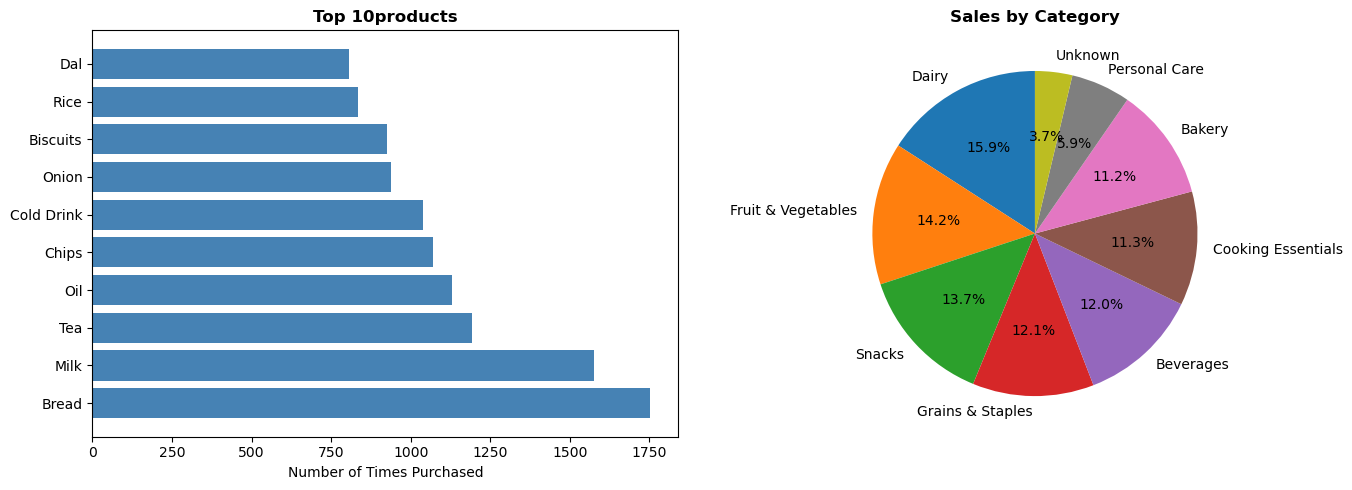

charts saved


In [99]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
#chart1:Top products
top_products=df['Product'].value_counts().head(10)
axes[0].barh(top_products.index,top_products.values,color='Steelblue')
axes[0].set_title('Top 10products',fontweight='bold')
axes[0].set_xlabel('Number of Times Purchased')
#chart2:sales by category
category_counts=df['Category'].value_counts()
axes[1].pie(category_counts.values,
            labels=category_counts.index,
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Sales by Category',fontweight='bold')
plt.tight_layout()
plt.savefig("cognicart/outputs/week1_charts.png",dpi=150)
plt.show()
print("charts saved")